In [1]:
import sys, os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

snapshot_files = sorted(glob.glob("data/weekly_snapshots/week_*.csv"))
all_weeks = pd.concat([pd.read_csv(f) for f in snapshot_files], ignore_index=True)
all_weeks.head()

,fan_id,week,engagement_score,tier,at_risk
0,1,1,41.500000,At Risk,False
1,2,1,59.666667,Engaged,False
2,3,1,71.033333,Engaged,False
3,4,1,42.200000,At Risk,False
4,5,1,72.100000,Engaged,False


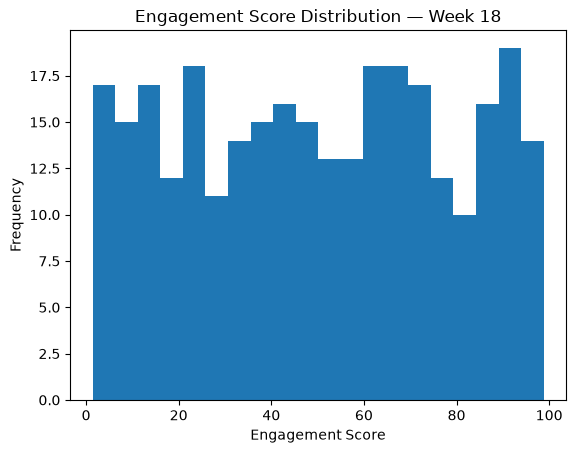

tier
Engaged      81
Dormant      76
At Risk      73
Super Fan    70
Name: count, dtype: int64

In [3]:
final_week = all_weeks["week"].max()
final = all_weeks[all_weeks["week"] == final_week]

final["engagement_score"].plot(kind="hist", bins=20, title=f"Engagement Score Distribution — Week {final_week}")
plt.xlabel("Engagement Score")
plt.show()

final["tier"].value_counts()

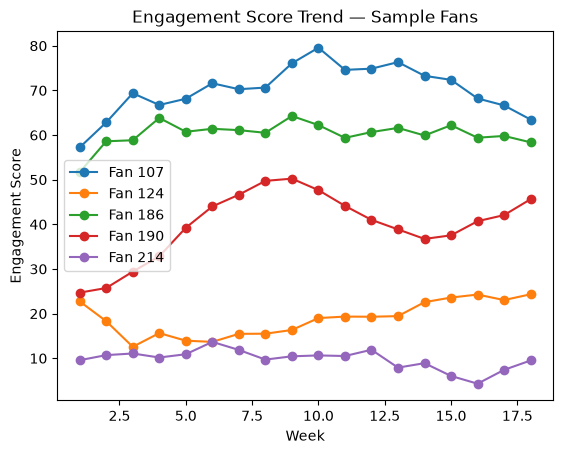

In [4]:
sample_fan_ids = all_weeks["fan_id"].drop_duplicates().sample(5, random_state=1)
sample = all_weeks[all_weeks["fan_id"].isin(sample_fan_ids)]

for fan_id, group in sample.groupby("fan_id"):
    plt.plot(group["week"], group["engagement_score"], marker="o", label=f"Fan {fan_id}")
plt.legend()
plt.title("Engagement Score Trend — Sample Fans")
plt.xlabel("Week")
plt.ylabel("Engagement Score")
plt.show()